# Grovera meklēšanas algoritms


Grovera algoritms ir kvantu algoritms, kas paredzēts nešķirotas meklēšanas problēmas risināšanai ar kvadrātisku paātrinājumu. Algoritma pamatā ir kvantu superpozīcija un interferencē balstīta amplitūdu pastiprināšana. \
Piemēram, izanalizēsim Grovera meklēšanas algoritmu un centīsimies atrast vienu marķēto stāvokli - $|1011\rangle$


### Sākuma stāvoklis

Vispirms visi kubiti tiek sagatavoti vienmērīgā superpozīcijā:
$$
|s\rangle = \frac{1}{\sqrt{N}} \sum_{x=0}^{N-1} |x\rangle.
$$

Četru kubitu gadījumā \(N = 16\), un katram stāvoklim, tostarp $|1011\rangle$
, sākotnējā amplitūda ir $\frac{1}{\sqrt{16}} = \frac{1}{4}.$

### Orākuls

Orākuls ir kvantu operators, kas atpazīst marķēto stāvokli un apgriež tā fāzi. Ja meklējam stāvokli $|1011\rangle$, orākula darbība ir:
$$
O|x\rangle =
\begin{cases}
-|x\rangle, & \text{ja } x = 1011 \\
\;\;\;|x\rangle, & \text{citādi}
\end{cases}
$$

Pēc orākula pielietošanas tikai stāvokļa $|1011\rangle$ amplitūda kļūst negatīva, bet visu pārējo stāvokļu amplitūdas nemainās. Šajā brīdī mērījuma varbūtības vēl nemainās, bet fāzes izmaiņa ir būtiska nākamajam solim.

### Difūzijas operators

Nākamais solis ir difūzijas operators: $D = 2|s\rangle\langle s| - I,$
kur $I$ ir identitātes operators. Difūzijas operators veic amplitūdu atspoguļošanu ap vidējo vērtību.

Tā kā pēc orākula stāvokļa $|1011\rangle$ amplitūda ir zem vidējās vērtības (negatīva), difūzijas operators to paceļ virs vidējā līmeņa, savukārt pārējo stāvokļu amplitūdas tiek nedaudz samazinātas.

### Grovera iterācija

Orākula un difūzijas operatora kombinācija veido vienu Grovera iterāciju: $G = D O.$

Matemātiski var parādīt, ka šī iterācija atbilst kvantu stāvokļa rotācijai divdimensionālā apakštelpā, ko nosaka:
- markētais stāvoklis $|1011\rangle$,
- visu nemarkēto stāvokļu superpozīcija.

Katra iterācija pagriež stāvokli par fiksētu leņķi $2\theta$, kur $\sin\theta = \frac{1}{\sqrt{N}}.$

Četru kubitu gadījumā:
$
\sin\theta = \frac{1}{4}.
$


### Iterāciju skaits



Optimālais Grovera iterāciju skaits viena markētā stāvokļa gadījumā ir:
$$
k \approx \frac{\pi}{4}\sqrt{N}.
$$

Tātad:
$$
k \approx \frac{\pi}{4}\sqrt{16} = \pi \approx 3.
$$

Pēc trim Grovera iterācijām stāvokļa $|1011\rangle$ amplitūda ir ļoti tuvu 1, bet pārējo stāvokļu amplitūdas ir tuvu nullei.

### Mērījums

Noslēgumā tiek veikts kvantu mērījums. Tā kā stāvokļa $|1011\rangle$ varbūtība ir dominējoša, mērījuma rezultāts ar ļoti lielu varbūtību būs tieši bitu virkne 1011.

### Kopsavilkums

Grovera algoritms neatrod pareizo stāvokli tieši, bet pakāpeniski pastiprina tā amplitūdu, izmantojot fāzes apgriešanu un kvantu interferenci. 



# Augsta līmeņa Grovera meklēšanas algoritms

* Netiek būvēta kvantu shēma

* Orākuls aprakstīts loģiski

* Iiterāciju skaitu izvēlas Qiskit

* Ancilla ir paslēpta



In [2]:
from qiskit_algorithms import Grover, AmplificationProblem
from qiskit.circuit.library import PhaseOracleGate
from qiskit.primitives import StatevectorSampler


# Mērķa stāvoklis, šajā piemērā |1011>
target_state = "1011"

# Orākula definīcija
# q3 = 1, q2 = 0, q1 = 1, q0 = 1
oracle_expression = "(q3 & ~q2 & q1 & q0 )"
oracle = PhaseOracleGate(oracle_expression)


# Grovera problēmas definēšana
# Qiskit mērījumu rezultātus atgriež pretējā virzienā

problem = AmplificationProblem(
    oracle=oracle,
    is_good_state=lambda bitstring: bitstring[::-1] == target_state
)

# Grovera algoritma inicializācija
sampler = StatevectorSampler()
grover = Grover(sampler=sampler)


# Grovera algoritma izpilde
result = grover.amplify(problem)


# Rezultātu izdruka
print("Top measurement (Qiskit bitu kārtība q0 q1 q2 q3):",
      result.top_measurement)

print("Top measurement (loģiskā kārtība |q3 q2 q1 q0>):",
      result.top_measurement[::-1])


ModuleNotFoundError: No module named 'qiskit_algorithms'

# Zema līmeņa Grovera meklēšanas algoritms
* kvantu shēma tiek būvēta ar vārtiem

* orākuls un difūzija ir redzami

* ancilla tiek izmantota tieši

* iterāciju skaitu kontrolē lietotājs

Mērījumu rezultāti:
0000 : 59
0001 : 53
0010 : 63
0011 : 66
0100 : 56
0101 : 59
0110 : 64
0111 : 74
1000 : 69
1001 : 46
1010 : 60
1011 : 59
1100 : 62
1101 : 9105
1110 : 46
1111 : 59


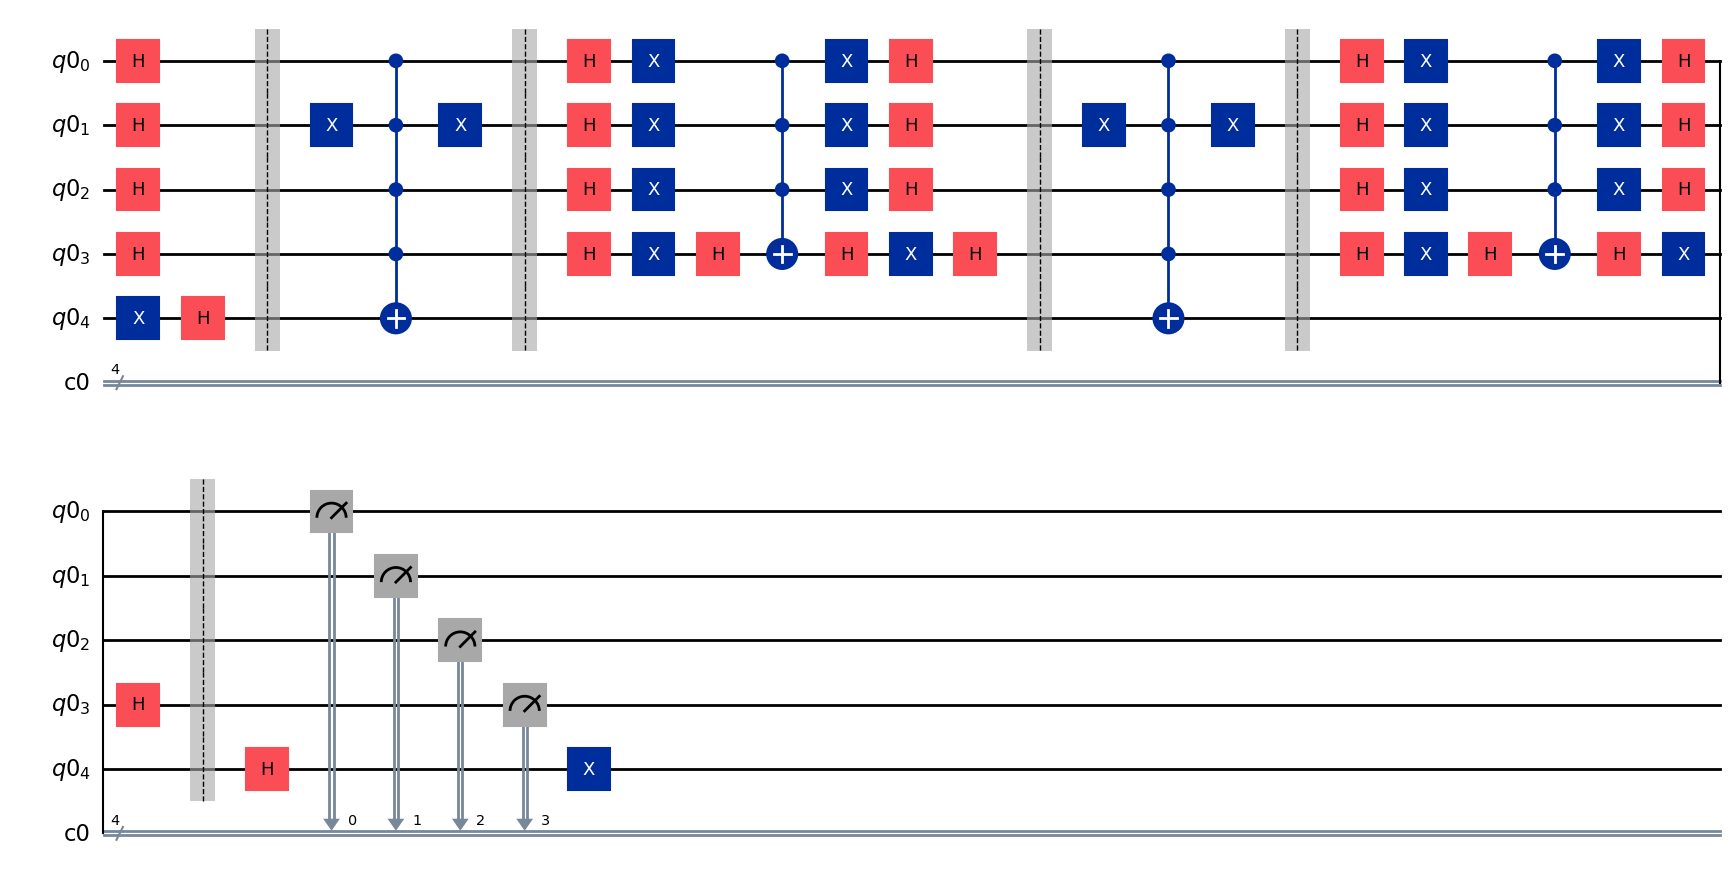

In [3]:

# Grovera meklēšana: 4 meklēšanas qubiti + 1 ancilla, jeb palīg qubits
# Mērķa stāvoklis: |1011>

from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_aer import AerSimulator

n_search = 4                 # meklēšanas qubitu skaits
target_state = "1011"        # meklējamais stāvoklis
grover_iterations = 2        # Grovera iterāciju skaits, 2 – labs rezultāts, 6 – redzama pāršaušana 
shots = 10000                

qreg = QuantumRegister(n_search + 1) # Pēdējais qubits tiek izmantots kā ancilla
creg = ClassicalRegister(n_search)
qc = QuantumCircuit(qreg, creg)

# Ancilla inicializācija stāvoklī |-> = (|0> - |1>)/√2
# Nepieciešams "phase kickback" realizācijai
qc.x(qreg[n_search])
qc.h(qreg[n_search])

#Meklēšanas qubitu ievietošana superpozīcijā
for i in range(n_search):
    qc.h(qreg[i])

qc.barrier()

#Orākula definēšana
# Apgriež fāzi tieši stāvoklim |1011>
def oracle(circuit, q):
    # Invertē tos qubitus, kuriem mērķa stāvoklī ir 0
    for i, bit in enumerate(target_state):
        if bit == "0":
            circuit.x(q[i])

    # Multi Controlled NOT uz ancilla qubita
    #realizē fāzes apgriešanu ar phase kickback
    circuit.mcx(q[:n_search], q[n_search])

    # Atgriež invertētos qubitus sākotnējā stāvoklī
    for i, bit in enumerate(target_state):
        if bit == "0":
            circuit.x(q[i])


# Difūzijas operators (inversion about the mean)
# Pastiprina mērķa stāvokļa amplitūdu
def diffusion(circuit, q):
    # Hadamard un X vārti uz meklēšanas qubitiem
    for i in range(n_search):
        circuit.h(q[i])
        circuit.x(q[i])

    # Multi kontrolēti Z vārti (realizēts ar MCX)
    circuit.h(q[n_search - 1])
    circuit.mcx(q[:n_search - 1], q[n_search - 1])
    circuit.h(q[n_search - 1])

    for i in range(n_search):
        circuit.x(q[i])
        circuit.h(q[i])


# Grovera iterācijas
for _ in range(grover_iterations):
    oracle(qc, qreg)
    qc.barrier()
    diffusion(qc, qreg)
    qc.barrier()


# Ancilla qubita atgriešana sākotnējā stāvoklī |0>
qc.h(qreg[n_search])
qc.x(qreg[n_search])


# Meklēšanas qubitu mērījumi
for i in range(n_search):
    qc.measure(qreg[i], creg[i])



sim = AerSimulator()
job = sim.run(qc, shots=shots)
counts = job.result().get_counts()

print("Mērījumu rezultāti:")
for outcome in sorted(counts):
    print(outcome, ":", counts[outcome])

qc.draw(output='mpl')
